# How to best start an HA in a blob-like city?¶

Let probability of starting in a zone be  𝑝(𝑥,𝑦)
 . If cars don't accumulate in the long-term (and they don't), then probability of ending in a zone is also  𝑝(𝑥,𝑦)
 .

If trips from any point to any point are equally probable (which is not true of course, but let's consider this ideal city for a second), then probability of traveling from  (𝑥1,𝑦1)
  to  (𝑥2,𝑦2)
  is equal to the product of probabilities  𝑝1
  and  𝑝2
 .

Therefore the expected revenue from points 1 and 2 is equal to  𝑝12𝑑12=𝑝1𝑝2𝑑12
 
Let's optimize  ∑𝑛𝑖𝑗𝑝𝑖𝑝𝑗𝑑𝑖𝑗
  for different values of n

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

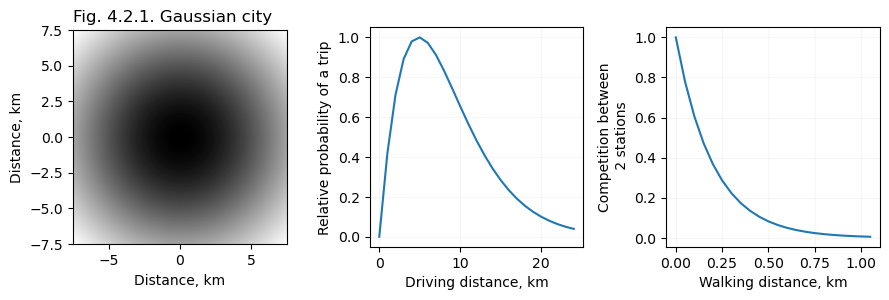

In [122]:
# Gaussian city + trip probability
city_width = 15 # km
grid_step = 0.1 # km
walking_distance = 0.2 # 200 meters of walking distance
sigma = 10 # Gaussian sigma

def ga(x, sigma):    
    d = x[:,0]**2 + x[:,1]**2 # 2D Gaussian    
    return np.exp(-d/sigma**2)

def trip_probability(d):
    y = d*np.exp(-(d**1.2)/8) / 2.11
    return y

x = np.arange(-city_width/2, city_width/2, grid_step)
xy = np.meshgrid(x,x)
xy = np.array([xy[0].flatten() , xy[1].flatten()]).T

# Figure
plt.figure(figsize=(9,3))
plt.subplot(131)
m = plt.gca().imshow(ga(xy, sigma).reshape((len(x),-1)), 
                     cmap='binary', extent=[-city_width/2 , city_width/2, -city_width/2, city_width/2])
plt.title("Fig. 4.2.1. Gaussian city", loc='left');
plt.xlabel('Distance, km')
plt.ylabel('Distance, km')

plt.subplot(132)
x = np.arange(0, 25)
plt.plot(x, trip_probability(x))
plt.grid(alpha=0.1)
plt.xlabel('Driving distance, km')
plt.ylabel('Relative probability of a trip');

plt.subplot(133)
x = np.arange(0, 1.1, 0.05)
plt.plot(x, np.exp(-x/walking_distance))
plt.grid(alpha=0.1)
plt.xlabel('Walking distance, km')
plt.ylabel('Competition between\n 2 stations');

plt.tight_layout()
plt.savefig("../figures/04oa_02stations_01gaussian_city.svg", dpi=300)

In [111]:
def score(x):
    # Total revenue on trips betweeen these points. X has dimensions of n_points by 2
    # Taken with a negative sign, as we are going to optimize (minimize) it
    x = np.reshape(x, (-1,2), order='F')
    d = np.sqrt((x[:,[0]] - x[:,[0]].T)**2 + (x[:,[1]] - x[:,[1]].T)**2)
    crowdness = np.exp(-d/walking_distance).sum(axis=0)
    p = ga(x, sigma) / (1+crowdness)
    return -p @ (d * trip_probability(d)) @ p.T
    
x = [0, 1, 0, 1]
score(x)

-0.3840426504357514

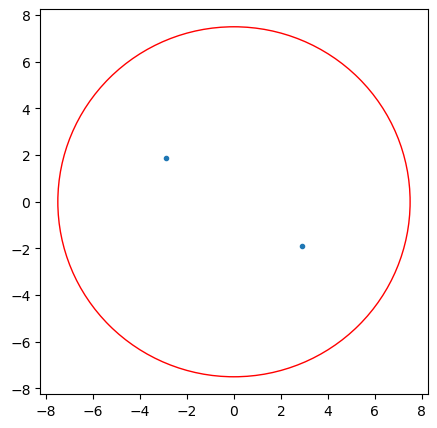

In [112]:
# Let's optimize positions of 2 stations explicitly
def optimize_for_n_points(n):
    x = np.random.randn(n*2)
    out = minimize(score, x)

    cir = plt.Circle((0,0), city_width/2, color='r', fill=False)
    plt.gca().add_patch(cir)    
    plt.plot(out.x[:n], out.x[n:], '.');

plt.figure(figsize=(5,5))
optimize_for_n_points(2)

......

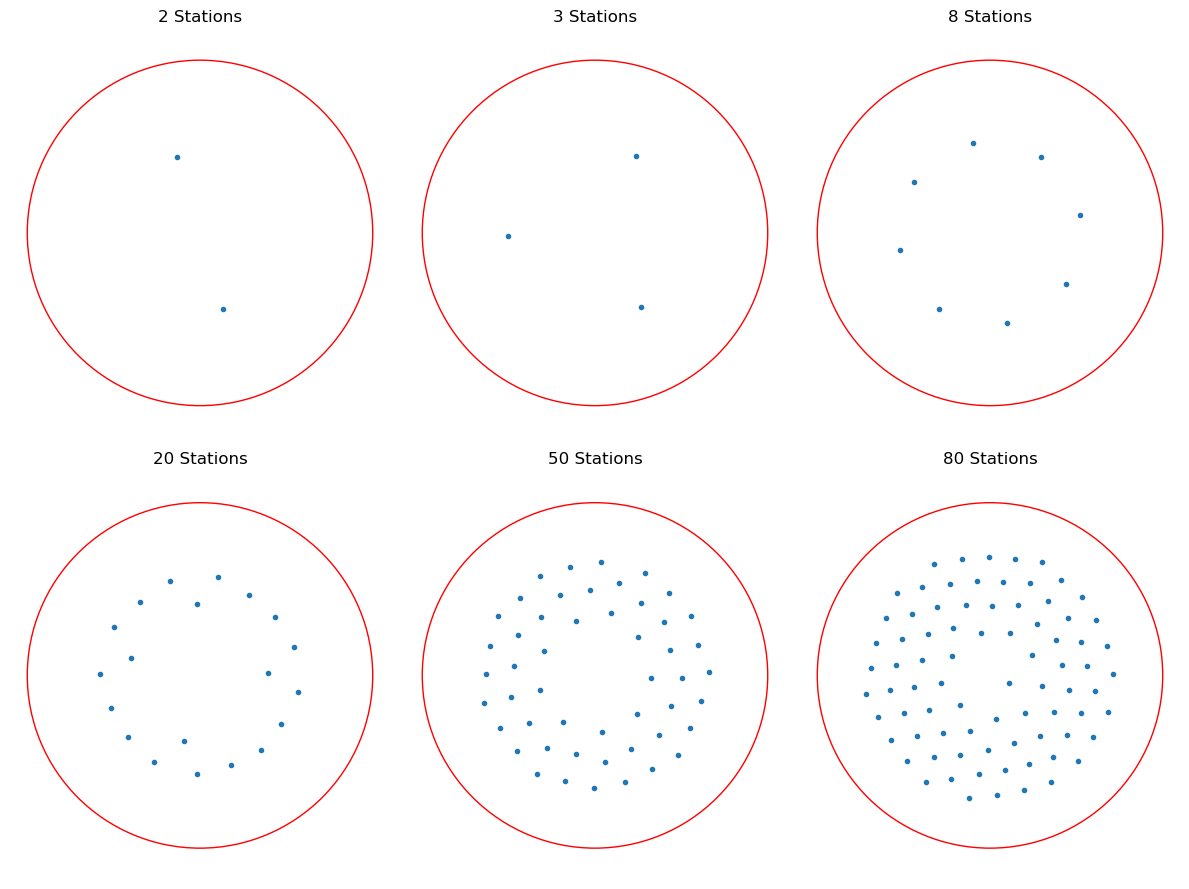

In [113]:
# For bigger number of stations
plt.figure(figsize=(12, 9))
for i,n in enumerate([2, 3, 8, 20, 50, 80]):
    plt.subplot(2, 3, i+1)
    optimize_for_n_points(n)
    plt.axis('equal')
    plt.axis('off')
    plt.title(f"{n} Stations")
    print('.', end='')
    
plt.tight_layout()
plt.savefig("../figures/04oa_02stations_02idealized.svg", dpi=300)